In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv("online_shoppers_intention_preprocessed.csv")  

X = df.drop('Revenue', axis=1)
y = df['Revenue']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
X_train_rnn = np.reshape(X_train_scaled, (X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_rnn = np.reshape(X_test_scaled, (X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

print(f"Reshaped X_train shape: {X_train_rnn.shape}")

Reshaped X_train shape: (9764, 17, 1)


In [6]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))
print(f"Class Weights applied: {class_weights_dict}")

Class Weights applied: {np.int64(0): np.float64(0.5940618155268922), np.int64(1): np.float64(3.1578266494178524)}


In [7]:
rnn_model = Sequential()
# First LSTM layer
rnn_model.add(LSTM(64, return_sequences=True, input_shape=(X_train_rnn.shape[1], 1)))
rnn_model.add(Dropout(0.3))
# Second LSTM layer
rnn_model.add(LSTM(32))
rnn_model.add(Dropout(0.3))
# Output layer
rnn_model.add(Dense(1, activation='sigmoid'))

C:\Users\Garkjf\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [10]:
history = rnn_model.fit(
    X_train_rnn,
    y_train,
    epochs=50,             
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights_dict, 
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5901 - loss: 0.6472 - val_accuracy: 0.6027 - val_loss: 0.6136
Epoch 2/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6137 - loss: 0.6275 - val_accuracy: 0.5704 - val_loss: 0.6627
Epoch 3/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6588 - loss: 0.6059 - val_accuracy: 0.7153 - val_loss: 0.5607
Epoch 4/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6651 - loss: 0.5892 - val_accuracy: 0.6226 - val_loss: 0.6375
Epoch 5/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6591 - loss: 0.5854 - val_accuracy: 0.6344 - val_loss: 0.6315
Epoch 6/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6648 - loss: 0.5795 - val_accuracy: 0.5730 - val_loss: 0.6769
Epoch 7/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6701 - loss: 0.5671 - val_accuracy: 0.6595 - val_loss: 0.5852
Epoch 8/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6618 - loss: 0.5651 - val_accu

In [11]:
y_prob_rnn = rnn_model.predict(X_test_rnn)
y_pred_rnn = (y_prob_rnn > 0.5).astype(int)

print("\n--- Model Evaluation ---")
print("RNN/LSTM Accuracy:", accuracy_score(y_test, y_pred_rnn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rnn))

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

--- Model Evaluation ---
RNN/LSTM Accuracy: 0.870954526833265

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.90      0.92      2079
           1       0.55      0.71      0.62       362

    accuracy                           0.87      2441
   macro avg       0.75      0.81      0.77      2441
weighted avg       0.89      0.87      0.88      2441



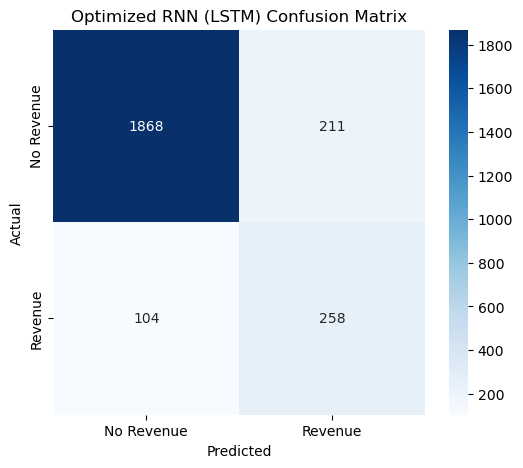

In [12]:
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred_rnn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Revenue','Revenue'],
            yticklabels=['No Revenue','Revenue'])
plt.title("Optimized RNN (LSTM) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rnn)
auc = roc_auc_score(y_test, y_prob_rnn)

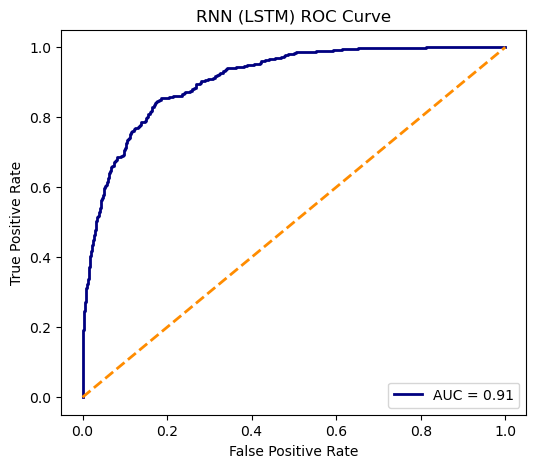

In [14]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}", color='navy', lw=2)
plt.plot([0,1],[0,1],'--', color='darkorange', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RNN (LSTM) ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [15]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_rnn)
ap_score = average_precision_score(y_test, y_prob_rnn)

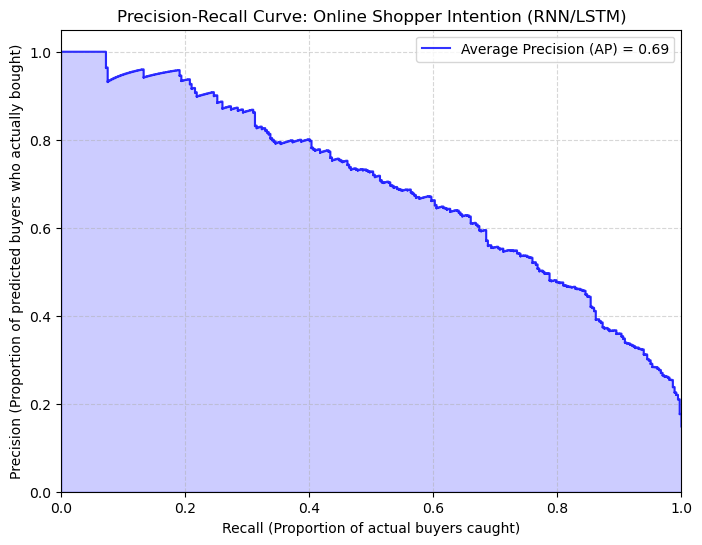

In [16]:
plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='b', alpha=0.8, where='post', label=f'Average Precision (AP) = {ap_score:.2f}')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')
plt.xlabel('Recall (Proportion of actual buyers caught)')
plt.ylabel('Precision (Proportion of predicted buyers who actually bought)')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve: Online Shopper Intention (RNN/LSTM)')
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [17]:
print(f"\nAverage Precision (AP): {ap_score:.4f}")


Average Precision (AP): 0.6945
